(1095, 20)
(260920, 17)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_dec

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches["winner"].value_counts().head(10).values,


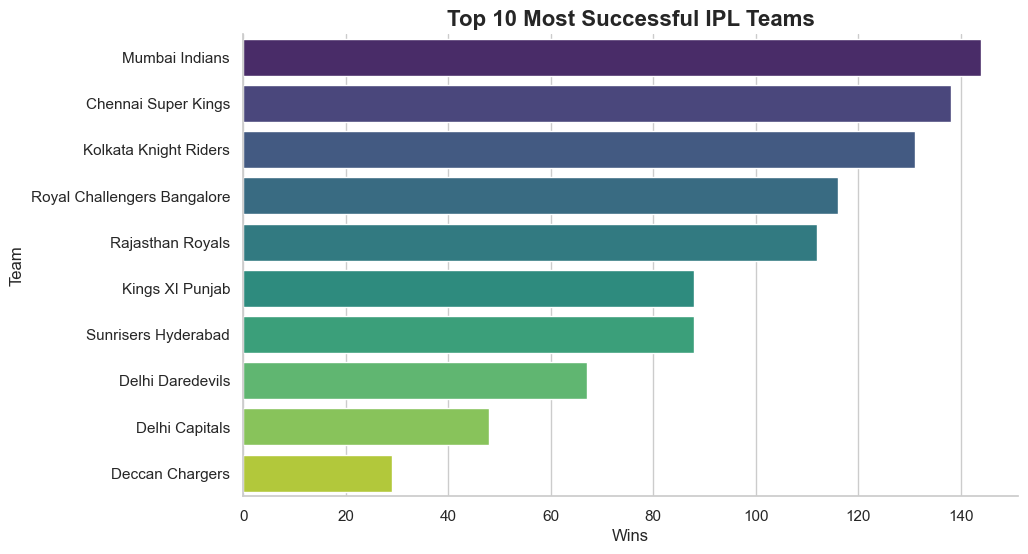

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=matches["toss_match_win"], palette="viridis")


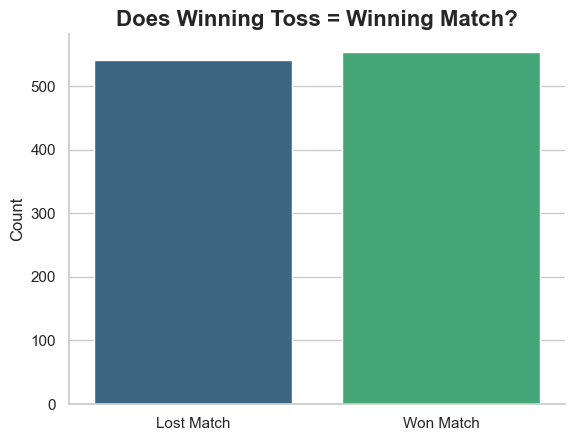

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=matches["toss_decision"], palette="viridis")


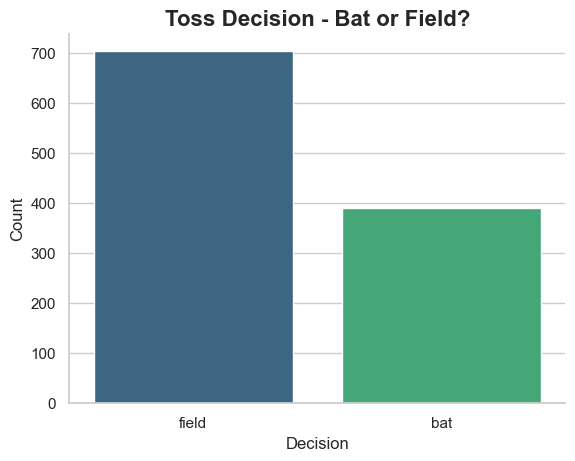

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches["player_of_match"].value_counts().head(10).values,


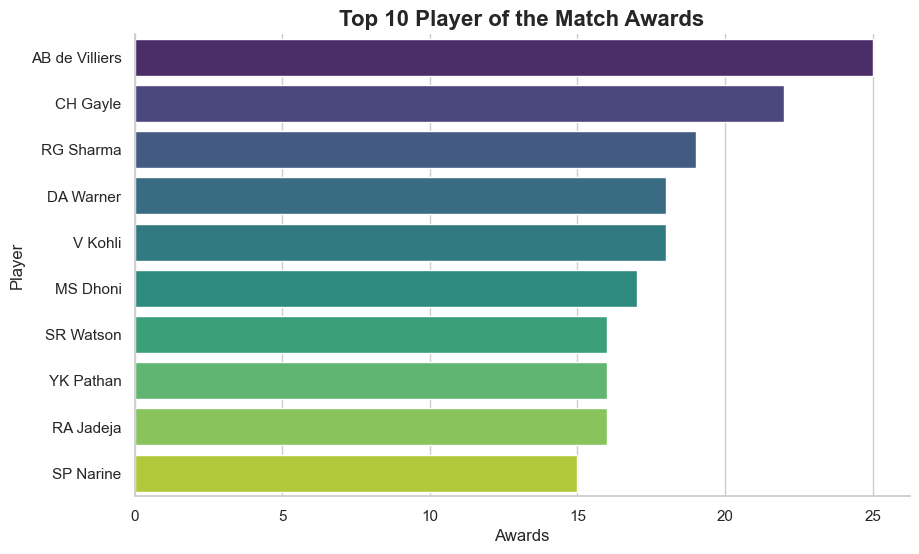

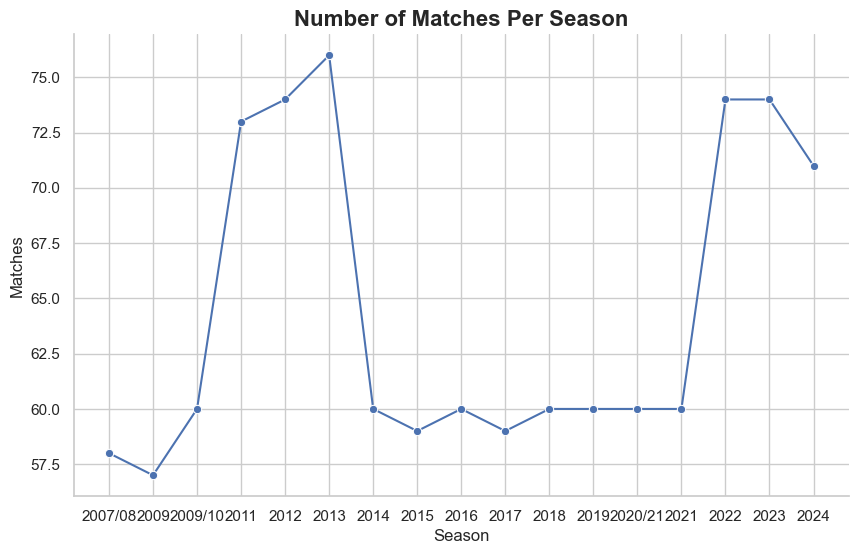

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette="viridis")


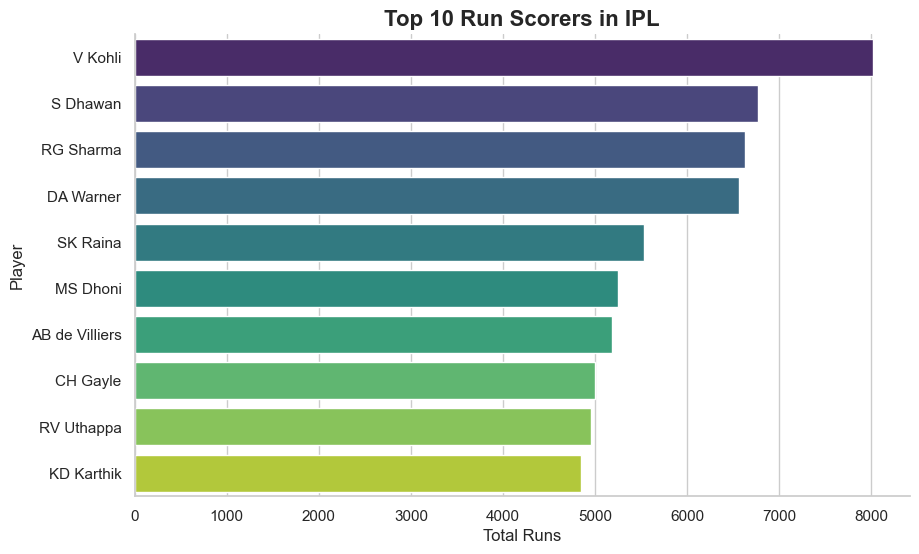

C:\Users\91910\AppData\Local\Temp\ipykernel_78192\3621352562.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_wickets.values, y=top_wickets.index, palette="viridis")


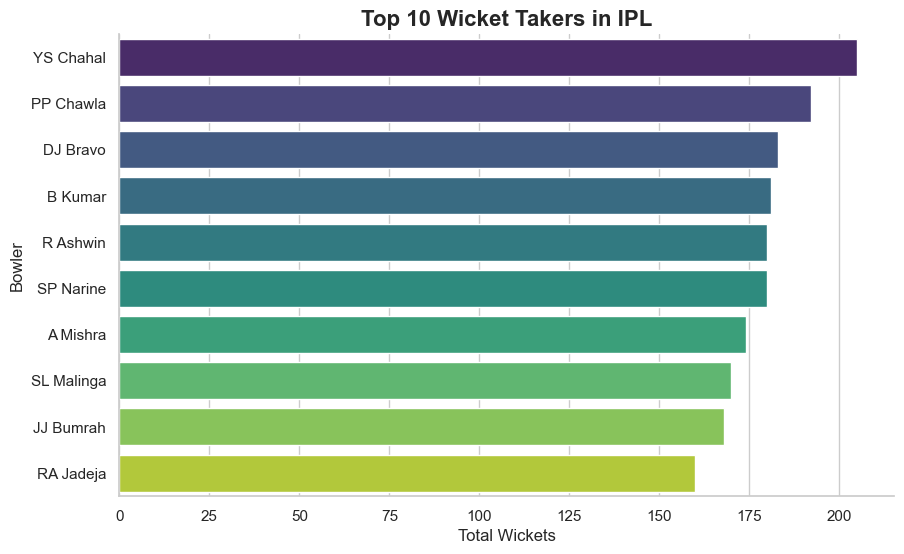

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

matches = pd.read_csv("archive/matches.csv")
deliveries = pd.read_csv("archive/deliveries.csv")

print(matches.shape)
print(deliveries.shape)

print(matches.head())
print("---")
print(matches.columns)
# most successful teams
matches["winner"].value_counts().head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x=matches["winner"].value_counts().head(10).values,
            y=matches["winner"].value_counts().head(10).index,
            palette="viridis")
plt.title("Top 10 Most Successful IPL Teams", fontsize=16, fontweight="bold")
plt.xlabel("Wins")
plt.ylabel("Team")
sns.despine()
plt.show()

# does winning toss help win the match?
matches["toss_match_win"] = matches["toss_winner"] == matches["winner"]

matches["toss_match_win"].value_counts()

sns.set_theme(style="whitegrid")
sns.countplot(x=matches["toss_match_win"], palette="viridis")
plt.title("Does Winning Toss = Winning Match?", fontsize=16, fontweight="bold")
plt.xticks([0, 1], ["Lost Match", "Won Match"])
plt.xlabel("")
plt.ylabel("Count")
sns.despine()
plt.show()

# what do teams choose after winning toss?
matches["toss_decision"].value_counts()

sns.set_theme(style="whitegrid")
sns.countplot(x=matches["toss_decision"], palette="viridis")
plt.title("Toss Decision - Bat or Field?", fontsize=16, fontweight="bold")
plt.xlabel("Decision")
plt.ylabel("Count")
sns.despine()
plt.show()

# who won player of the match the most?
matches["player_of_match"].value_counts().head(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x=matches["player_of_match"].value_counts().head(10).values,
            y=matches["player_of_match"].value_counts().head(10).index,
            palette="viridis")
plt.title("Top 10 Player of the Match Awards", fontsize=16, fontweight="bold")
plt.xlabel("Awards")
plt.ylabel("Player")
sns.despine()
plt.show()

# how many matches per season?
matches["season"].value_counts().sort_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
season_counts = matches["season"].value_counts().sort_index()
sns.lineplot(x=season_counts.index, y=season_counts.values, marker="o")
plt.title("Number of Matches Per Season", fontsize=16, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Matches")
sns.despine()
plt.show()

# top 10 run scorers across all IPL seasons
deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
top_scorers = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette="viridis")
plt.title("Top 10 Run Scorers in IPL", fontsize=16, fontweight="bold")
plt.xlabel("Total Runs")
plt.ylabel("Player")
sns.despine()
plt.show()

# top 10 wicket takers
wickets = deliveries[deliveries["dismissal_kind"].notna()]
wickets = wickets[~wickets["dismissal_kind"].isin(["run out", "retired hurt", "obstructing the field"])]

wickets.groupby("bowler")["dismissal_kind"].count().sort_values(ascending=False).head(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
top_wickets = wickets.groupby("bowler")["dismissal_kind"].count().sort_values(ascending=False).head(10)
sns.barplot(x=top_wickets.values, y=top_wickets.index, palette="viridis")
plt.title("Top 10 Wicket Takers in IPL", fontsize=16, fontweight="bold")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
sns.despine()
plt.show()

## Conclusions

1. Mumbai Indians are the most successful IPL team with 144 wins
2. Winning the toss barely matters — almost 50/50 win rate
3. Most teams prefer to field after winning toss (704 vs 391)
4. AB de Villiers is the Player of the Match MVP
5. Virat Kohli is the all time top run scorer
6. SL Malinga is the all time top wicket taker